# Detection of Covid-19 from Chest-X-ray

In [4]:
# Import the required modules
import numpy as np
import pandas as pd
import tensorflow as tf
import keras_preprocessing
from keras_preprocessing import image
from keras_preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

In [34]:
# pip install keras_preprocessing

# Data ingesting of Covid 19 images

## COVID and Normal dataset directory
## Method No 1: Using Kaggle

In [35]:
#install kaggle
# ! pip install kaggle

In [41]:
! kaggle datasets download alifrahman/covid19-chest-xray-image-dataset

Dataset URL: https://www.kaggle.com/datasets/alifrahman/covid19-chest-xray-image-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
covid19-chest-xray-image-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)


In [42]:
! mkdir train

mkdir: cannot create directory ‘train’: File exists


In [43]:
! unzip /content/covid19-chest-xray-image-dataset.zip

Archive:  /content/covid19-chest-xray-image-dataset.zip
replace dataset/covid/01E392EE-69F9-4E33-BFCE-E5C968654078.jpeg? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [45]:
BASIS_DIR = '/content/dataset'
CLASSES = ["covid",  "normal"]

## Method No 2: Data ingest using Google Drive

In [31]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [27]:
BASIS_DIR = '/content/drive/MyDrive/dataset '
CLASSES = ["covid",  "normal"]

# Method No 3: Data ingest using Direct method

In [ ]:
BASIS_DIR = '/content/sample_data/dataset method 3'
CLASSES = ["covid",  "normal"]

# Method No 4: Data ingest using Local on-premises

In [ ]:
# COVID and Normal dataset directory
BASIS_DIR = 'D:/DataSet/COVID_CHEST_XRAY'
classes=["COVID_",  "Normal_"]

# Image augmentation process:

In [46]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    horizontal_flip=True,
    shear_range = 0.2,
    zoom_range = 0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    fill_mode = 'nearest',

    #split dataset to training(80%) and validation(20%):
    validation_split=0.2
)

# Training dataset and Validation dataset:

In [47]:
train_data = train_datagen.flow_from_directory(
    directory=BASIS_DIR,
    target_size=(299, 299),
    batch_size=32,
    shuffle=True,
    class_mode='binary',
    subset='training',
    classes=CLASSES
    )

Found 76 images belonging to 2 classes.


In [48]:
val_data = train_datagen.flow_from_directory(
    directory=BASIS_DIR,
    target_size=(299, 299),
    batch_size=32,
    shuffle=True,
    class_mode='binary',
    subset='validation',
    classes=CLASSES
    )

Found 18 images belonging to 2 classes.


# Using sequential model:

In [49]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(299, 299, 3)),
    tf.keras.layers.MaxPooling2D(2, 2),

    tf.keras.layers.Conv2D(32, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

In [50]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 297, 297, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 148, 148, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 146, 146, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 73, 73, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 71, 71, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 35, 35, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 33, 33, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,297,057 (16.39 MB)

 Trainable params: 4,297,057 (16.39 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
# (filter_height*filter_width*number_of_channels+1)*number_of_filters
(3*3*32+1)*32

9248

In [51]:
# Compiling model with 'adam' optimizer loss function 'binary_crossentropy'
model.compile(loss='binary_crossentropy',
              optimizer=tf.optimizers.Adam(),
              metrics=['accuracy']
             )

In [58]:
# Training process:
number_epochs = 10
# You can change number_epochs above. But the bigger the value, the more time it takes for training
history = model.fit(train_data, epochs=number_epochs,
                    validation_data=val_data, verbose=2)

Epoch 1/10
3/3 - 20s - 7s/step - accuracy: 0.7368 - loss: 0.5252 - val_accuracy: 0.7778 - val_loss: 0.5000
Epoch 2/10
3/3 - 16s - 5s/step - accuracy: 0.7632 - loss: 0.4642 - val_accuracy: 0.7222 - val_loss: 0.4375
Epoch 3/10
3/3 - 16s - 5s/step - accuracy: 0.8026 - loss: 0.4556 - val_accuracy: 0.8333 - val_loss: 0.3942
Epoch 4/10
3/3 - 16s - 5s/step - accuracy: 0.8158 - loss: 0.3706 - val_accuracy: 0.9444 - val_loss: 0.2295
Epoch 5/10
3/3 - 16s - 5s/step - accuracy: 0.8158 - loss: 0.3701 - val_accuracy: 0.6667 - val_loss: 0.4584
Epoch 6/10
3/3 - 17s - 6s/step - accuracy: 0.8684 - loss: 0.3302 - val_accuracy: 0.7778 - val_loss: 0.3641
Epoch 7/10
3/3 - 19s - 6s/step - accuracy: 0.8684 - loss: 0.3084 - val_accuracy: 0.8333 - val_loss: 0.3372
Epoch 8/10
3/3 - 16s - 5s/step - accuracy: 0.8684 - loss: 0.2794 - val_accuracy: 0.7222 - val_loss: 0.3448
Epoch 9/10
3/3 - 16s - 5s/step - accuracy: 0.8947 - loss: 0.2764 - val_accuracy: 0.8889 - val_loss: 0.2333
Epoch 10/10
3/3 - 16s - 5s/step - acc

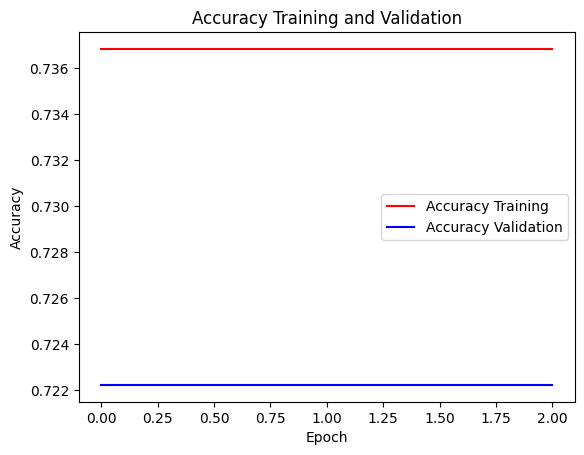

In [53]:
# Plotting training accuracy and validation accuracy
plt.plot(history.history['accuracy'], 'r', label='Accuracy Training')
plt.plot(history.history['val_accuracy'], 'b', label='Accuracy Validation')
plt.title('Accuracy Training and Validation')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc=0)
plt.show()

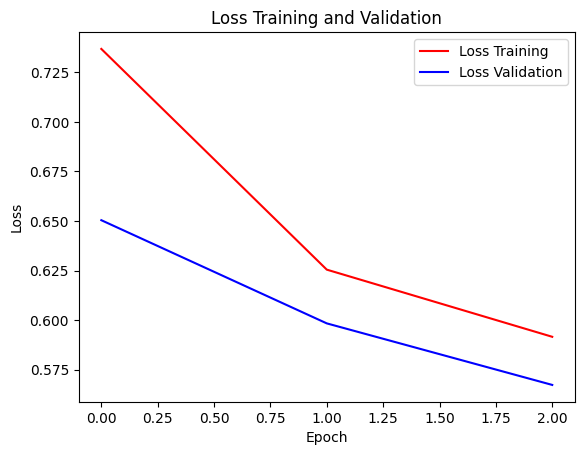

In [54]:
# Plotting training loss and validation loss
plt.plot(history.history['loss'], 'r', label='Loss Training')
plt.plot(history.history['val_loss'], 'b', label='Loss Validation')
plt.title('Loss Training and Validation')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc=0)
plt.show()

In [55]:
import tensorflow as tf
from tensorflow.keras.models import save_model
# Save the compiled model to an keras file
model.save('my_model.keras')

# Test random image

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 266ms/step
NORMAL


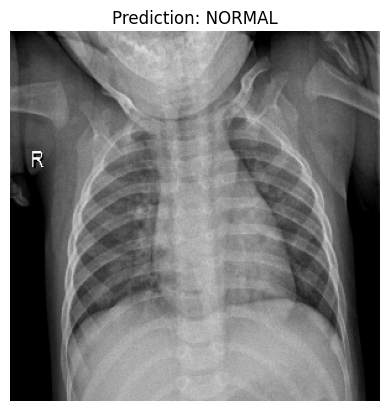

In [56]:
import numpy as np
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt

# Assuming you have a pre-trained model saved as 'your_model.h5'
model = load_model('my_model.keras')

path = "/content/dataset/normal/IM-0131-0001.jpeg"
img = image.load_img(path, target_size=(299, 299))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

result = model.predict(img_array)

# Assuming your model output has two classes (COVID and Normal)
threshold = 0.5
prediction = "COVID" if result[0][0] > threshold else "NORMAL"
print(prediction)

# Display the image
plt.imshow(img)
plt.title(f"Prediction: {prediction}")
plt.axis('off')  # Hide the axes
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 260ms/step
NORMAL


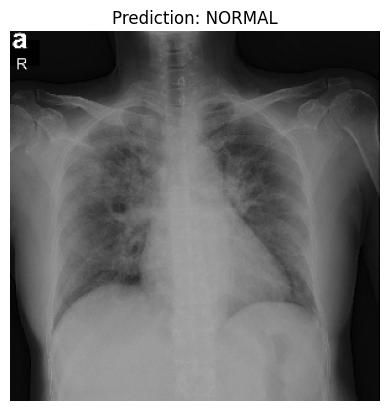

In [57]:
import numpy as np
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt

# Assuming you have a pre-trained model saved as 'your_model.h5'
model = load_model('my_model.keras')

path = "/content/dataset/covid/1-s2.0-S0929664620300449-gr2_lrg-a.jpg"
img = image.load_img(path, target_size=(299, 299))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

result = model.predict(img_array)

# Assuming your model output has two classes (COVID and Normal)
threshold = 0.5
prediction = "COVID" if result[0][0] > threshold else "NORMAL"
print(prediction)

# Display the image
plt.imshow(img)
plt.title(f"Prediction: {prediction}")
plt.axis('off')  # Hide the axes
plt.show()
